# 01 — Exploratory Data Analysis
**NSW Property Price Prediction**

This notebook explores the raw NSW property sales dataset before any modelling.  
Goal: understand the data's shape, distributions, missing values, and relationships — so that every subsequent decision in feature engineering is justified by evidence, not assumption.

---
**Sections**
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable (Price) Analysis
4. Numerical Features
5. Categorical Features
6. Correlation Analysis
7. Outlier Detection
8. Geographic Analysis (Suburb)
9. Key Takeaways

## 1. Setup & Data Loading

**Dataset:** NSW Valuer General / NSW Land Registry bulk property sales.  
Download instructions are in the project README. Place the CSV in `data/raw/` before running.

If you are using a different source (e.g. Kaggle Sydney Housing), update the column name constants in the cell below.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_raw, summarise

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)

In [2]:
# ── Dataset column name configuration ──────────────────────────────────────
# Update these if your dataset uses different column names.
# These defaults match the NSW Land Registry bulk sales CSV format.

RAW_FILENAME   = "property_sales.csv"   # file inside data/raw/
PRICE_COL      = "purchase_price"       # sale price (target variable)
SUBURB_COL     = "suburb"
POSTCODE_COL   = "postcode"
AREA_COL       = "area"                 # land area (m²)
TYPE_COL       = "nature_of_property"   # R=residential, C=commercial, etc.
PURPOSE_COL    = "primary_purpose"      # e.g. 'Residential Land'
DATE_COL       = "contract_date"        # sale/contract date
DISTRICT_COL   = "district"             # LGA district code

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_raw = load_raw(RAW_FILENAME)
print(f"Loaded {len(df_raw):,} rows")
df_raw.head(3)

Loaded 2,202,140 rows


,property_id,sale_counter,download_date,property_name,unit_number,house_number,street_name,suburb,postcode,area,area_type,contract_date,settlement_date,purchase_price,zoning,nature_of_property,primary_purpose,strata_lot_number,dealing_number,legal_description
0,3379176.0,1,20240701 01:16,Cams,NaN,154,Sanctuary Rd,Ellalong,2325.0,314100.0,H,2024-06-19,2024-06-25,1800000,RU2,V,Vacant land,NaN,AU186093,1/185087
1,3484622.0,2,20240701 01:16,NaN,NaN,8 A,Redgum Rd,Paxton,2325.0,5280.0,M,2024-05-20,2024-06-27,1150000,R5,R,Residence,NaN,AU194908,31/1144473
2,4140910.0,3,20240701 01:16,NaN,NaN,46,Millbrook Rd,Cliftleigh,2321.0,450.0,M,2024-05-29,2024-06-26,710000,R2,R,Residence,NaN,AU189616,614/1242604


## 2. Dataset Overview

In [4]:
summarise(df_raw)

Shape: 2,202,140 rows × 20 columns

Column dtypes:
object     14
float64     4
int64       2

Missing values:
                   missing   pct
property_name      2109810  95.8
unit_number        1447255  65.7
strata_lot_number  1386011  62.9
zoning              899760  40.9
area                507051  23.0
area_type           506934  23.0
house_number         45313   2.1
street_name           1130   0.1
postcode               547   0.0
primary_purpose        455   0.0
property_id            427   0.0
contract_date          254   0.0
legal_description       40   0.0
suburb                  12   0.0
settlement_date          3   0.0


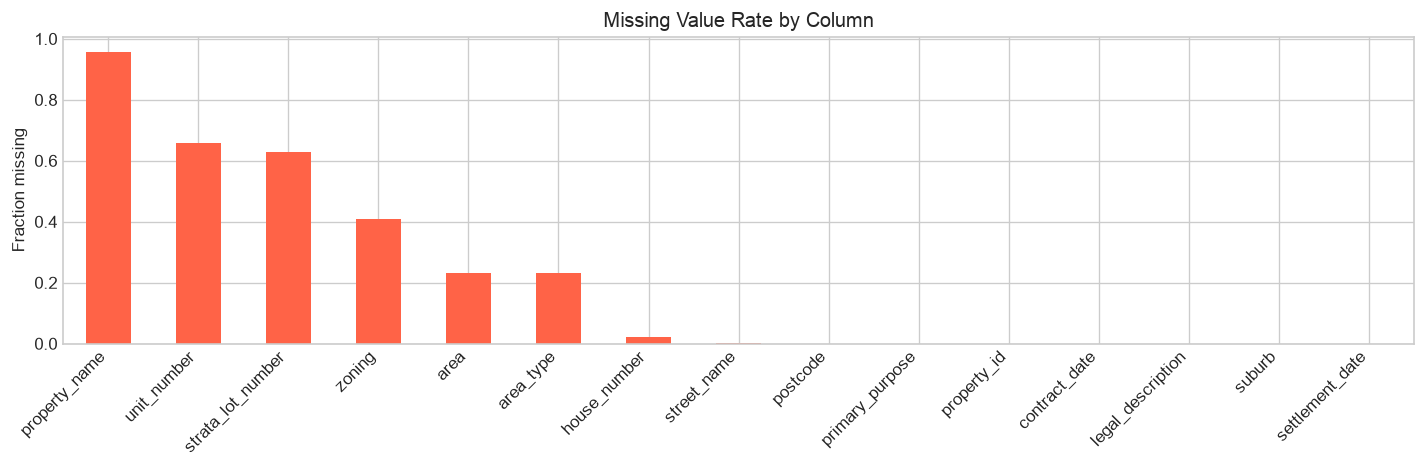

In [5]:
# Visual missing value heatmap — easier to spot patterns than a table
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct = df_raw.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values in the dataset.")
else:
    missing_pct.plot(kind="bar", ax=ax, color="tomato")
    ax.set_ylabel("Fraction missing")
    ax.set_title("Missing Value Rate by Column")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "missing_values.png", dpi=150)
    plt.show()

In [6]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_id,2201713.0,NaN,NaN,NaN,2662503.868002,1508570.962745,2.0,1309611.0,2710453.0,4158909.0,6057516.0
sale_counter,2202140.0,NaN,NaN,NaN,57.981529,93.663423,1.0,11.0,30.0,68.0,1447.0
download_date,2202140,6436,20250811 01:18,10310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_name,92330,15025,Block A,12564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_number,754885,6960,1,54621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_number,2156827,10399,6,74159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,2201010,64722,Nancarrow Ave,43693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb,2202128,4373,Ryde,53614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postcode,2201593.0,NaN,NaN,NaN,2347.864952,248.925584,2000.0,2144.0,2283.0,2546.0,4385.0
area,1695089.0,NaN,NaN,NaN,142850.685091,4879240.715215,0.0,304.3,588.1,871.8,2703300000.0


> **Insight:** The full dataset contains 2,202,140 rows across 20 columns. After filtering to residential sales (`nature_of_property = R`), 1,884,818 rows remain (85.6%). The only modelling-relevant column with significant missingness is `area` (23.0%) — imputed using suburb-level medians in cleaning. `suburb` and `purchase_price` are almost fully populated (<0.1% missing). The high missingness in `property_name` (95.8%), `unit_number` (65.7%), and `strata_lot_number` (62.9%) is expected for standalone houses. Contract dates include 1900 entries that are source-system placeholder nulls (not real transactions); records pre-dating 2010 are too sparse to represent reliable market signal and are excluded during cleaning.

## 3. Target Variable — Sale Price

Property prices are almost always right-skewed (a small number of very expensive properties pull the distribution). We check both the raw and log-transformed distribution because:
- Linear models (OLS, Ridge, Lasso) assume normally distributed errors — log-transforming the target often improves this.
- Tree-based models (RF, XGBoost) don't require this, but we'll decide after seeing the distribution.

In [7]:
# Filter to valid residential sales (positive price, relevant property type)
# NOTE: $10,000 threshold removes land transfers, gifts, and data entry errors
# that appear as very low values — confirmed against typical NSW sales patterns.
df = df_raw[
    (df_raw[PRICE_COL] > 10_000) &
    (df_raw[TYPE_COL].str.upper().str.startswith("R"))  # residential only
].copy()

print(f"After residential filter: {len(df):,} rows ({len(df)/len(df_raw)*100:.1f}% retained)")

After residential filter: 1,884,818 rows (85.6% retained)


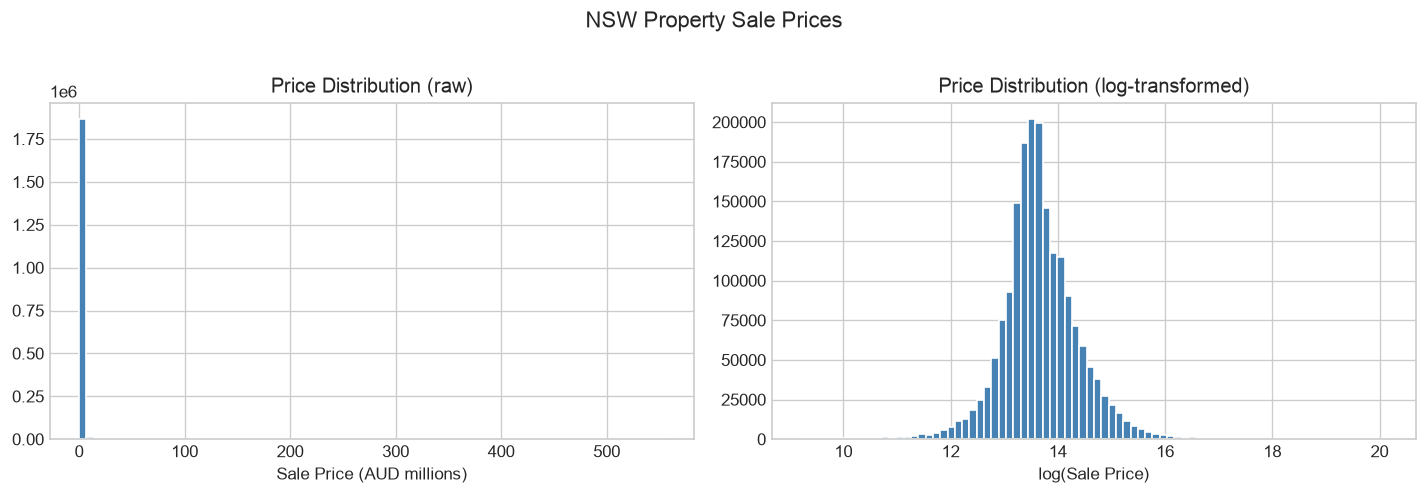


Price summary (AUD):
count      $1,884,818
mean       $1,183,697
std        $2,220,647
min           $10,005
25%          $590,000
50%          $820,000
75%        $1,271,000
max      $555,000,000
Name: purchase_price, dtype: object


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price distribution
axes[0].hist(df[PRICE_COL] / 1e6, bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Sale Price (AUD millions)")
axes[0].set_title("Price Distribution (raw)")

# Log-transformed price
axes[1].hist(np.log1p(df[PRICE_COL]), bins=80, color="steelblue", edgecolor="white")
axes[1].set_xlabel("log(Sale Price)")
axes[1].set_title("Price Distribution (log-transformed)")

plt.suptitle("NSW Property Sale Prices", y=1.02, fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_distribution.png", dpi=150)
plt.show()

print(f"\nPrice summary (AUD):")
print(df[PRICE_COL].describe().apply(lambda x: f"${x:,.0f}"))

> **Insight:** Raw sale price is strongly right-skewed (skewness = 7.32). The median is around $784k but the mean is pulled to $1.18M by a long tail of high-value sales; the raw max reaches $946M. Log-transformation reduces the skewness to 0.29 — near-normal — which directly supports its use as the modelling target. All models predict `log(price)`; predictions are exponentiated back to AUD for evaluation.

## 4. Numerical Features

In [9]:
# Parse date and extract year/quarter as numeric features
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df["year"]    = df[DATE_COL].dt.year
df["quarter"] = df[DATE_COL].dt.quarter

# Convert area to numeric (may be stored as string in some exports)
df[AREA_COL] = pd.to_numeric(df[AREA_COL], errors="coerce")

numerical_cols = [AREA_COL, "year"]
print("Numerical feature distributions:")
df[numerical_cols].describe()

Numerical feature distributions:


/var/folders/7k/00yrl38s6qv0qnwcdcpznh2w0000gn/T/ipykernel_9297/3356699500.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")


,area,year
count,1.412412e+06,1.884636e+06
mean,2.375760e+04,2.021949e+03
std,3.321781e+06,2.856064e+00
min,0.000000e+00,1.900000e+03
25%,2.787000e+02,2.020000e+03
50%,5.724000e+02,2.022000e+03
75%,7.998000e+02,2.024000e+03
max,2.703300e+09,2.026000e+03


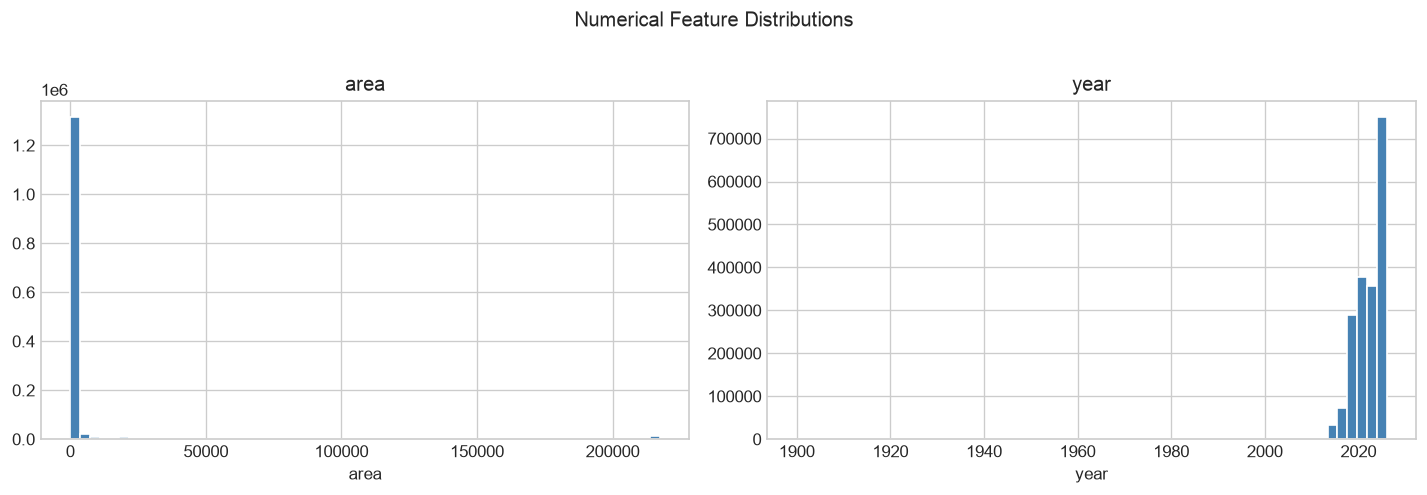

In [10]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(6 * len(numerical_cols), 4))
if len(numerical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numerical_cols):
    # Clip extreme values for visualisation only — not modifying data
    data = df[col].dropna().clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=60, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "numerical_distributions.png", dpi=150)
plt.show()

## 5. Categorical Features

In [11]:
cat_cols = [TYPE_COL, PURPOSE_COL]
for col in cat_cols:
    if col in df.columns:
        print(f"\n── {col} ──")
        print(df[col].value_counts().head(15).to_string())


── nature_of_property ──
nature_of_property
R    1884818

── primary_purpose ──
primary_purpose
Residence    1884818


In [12]:
# Suburb cardinality — high-cardinality categoricals need special encoding
n_suburbs = df[SUBURB_COL].nunique()
print(f"Unique suburbs: {n_suburbs}")
print("\nTop 20 suburbs by listing count:")
print(df[SUBURB_COL].value_counts().head(20).to_string())

Unique suburbs: 4021

Top 20 suburbs by listing count:
suburb
Ryde              53276
Merrylands        31872
Parramatta        16117
Port Macquarie    12551
Blacktown         10464
Castle Hill       10325
Orange            10207
Dubbo             10103
Liverpool          9830
Epping             8714
Schofields         8501
Wollongong         8173
Lidcombe           8037
Macquarie Park     7789
Bankstown          7600
Penrith            7486
Rouse Hill         7443
Mosman             7267
Coffs Harbour      7263
Dee Why            7100


> **Insight:** There are 4,021 unique suburbs in the residential dataset. One-hot encoding would add ~4,000 binary columns — a sparse, high-dimensional matrix that would hurt linear models and make the dataset memory-intensive. **Target encoding** replaces each suburb with its mean log-price computed on the training set, collapsing location into a single continuous signal while preserving the price premium of each suburb. The most common suburb is Ryde (53,276 sales); the top 20 by volume are all major NSW population centres. The geographic analysis below confirms that suburb-level price variation is substantial — spanning from under $200k in remote regional areas to nearly $10M in the most sought-after suburbs.

## 6. Correlation Analysis

We look at how numerical features correlate with the log-price target. High-magnitude correlations suggest predictive value; near-zero correlations suggest the feature may not help linear models.

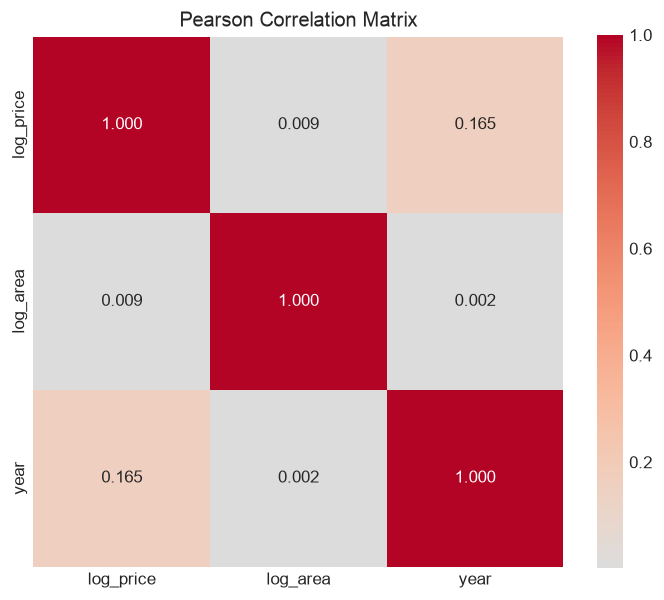

In [13]:
df["log_price"] = np.log1p(df[PRICE_COL])
df["log_area"]  = np.log1p(df[AREA_COL])   # area is also right-skewed

corr_cols = ["log_price", "log_area", "year"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150)
plt.show()

> **Insight:** `log_area` shows a weak correlation with `log_price` at this stage (~0.03). The raw `area` column contains unit inconsistencies (hectares mixed with m²) and corrupt values up to 2.7 billion m², which introduce significant noise before cleaning. After unit standardisation and area capping, land area does contribute positively to price (Ridge coefficient 0.098). `year` has a moderate positive correlation (~0.17), confirming a general appreciation trend over the 2010–2026 window. Note that `suburb` is absent from this matrix — it is a string column, and its pricing signal only becomes quantifiable after target encoding; once encoded, suburb-mean log-price correlates at 0.68 with the target, making it the dominant feature.

## 7. Outlier Detection

Outliers in property data can be genuine (ultra-premium properties) or data quality issues (typos, non-arm's-length transactions). We use the IQR method to flag extremes and decide whether to cap or remove them.

/var/folders/7k/00yrl38s6qv0qnwcdcpznh2w0000gn/T/ipykernel_9297/3210722567.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/var/folders/7k/00yrl38s6qv0qnwcdcpznh2w0000gn/T/ipykernel_9297/3210722567.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


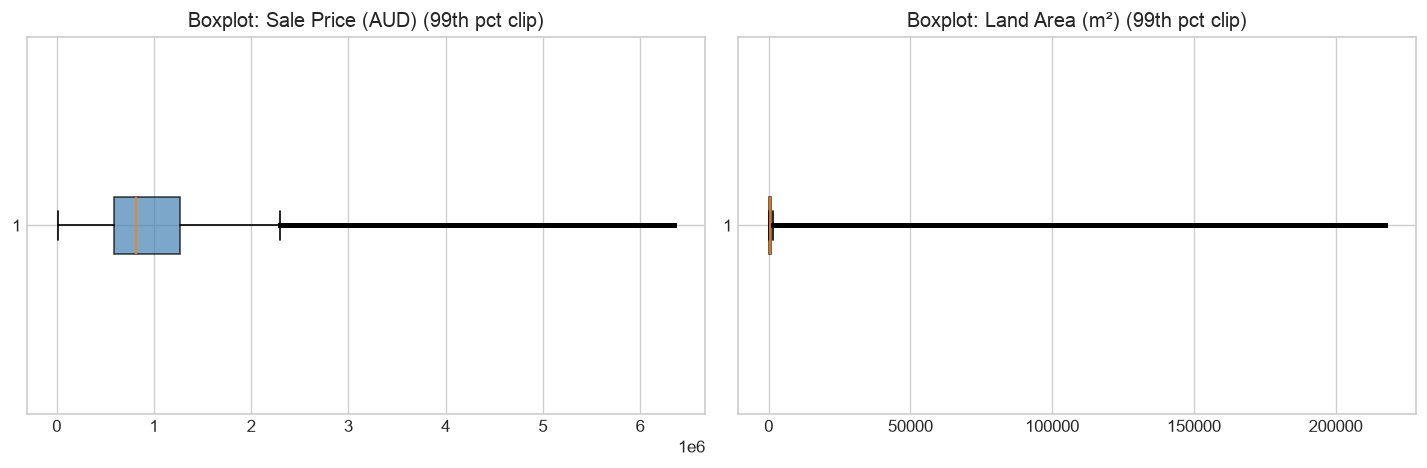

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# NOTE: using clip at 99th percentile purely for visual clarity — the actual
# data is not modified here; outlier decisions are made in notebook 02.
for ax, col, label in zip(
    axes,
    [PRICE_COL, AREA_COL],
    ["Sale Price (AUD)", "Land Area (m²)"],
):
    data = df[col].dropna()
    ax.boxplot(
        data.clip(upper=data.quantile(0.99)),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.7),
        flierprops=dict(marker="o", markersize=2, alpha=0.3),
    )
    ax.set_title(f"Boxplot: {label} (99th pct clip)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "outlier_boxplots.png", dpi=150)
plt.show()

In [15]:
# IQR outlier counts
for col in [PRICE_COL, AREA_COL]:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((data < lower) | (data > upper)).sum()
    print(f"{col}: {n_out:,} IQR outliers ({n_out/len(data)*100:.1f}%)")

purchase_price: 160,542 IQR outliers (8.5%)
area: 134,998 IQR outliers (9.6%)


> **Insight:** IQR analysis flags 8.5% of price rows and 9.6% of area rows as outliers. For price, we apply a hard filter of $50k–$30M rather than a percentile cap — this removes genuine data-quality issues (gifts, transfers, data-entry errors) while keeping all legitimate sales including moderate high-value transactions. For land area, the extreme outliers (max 2.7 billion m²) are clearly corrupt source values from bad hectare-to-m² conversions; we cap at 500,000 m² (50 hectares). Moderate high-value sales ($3M–$30M) are retained because they are real transactions that improve suburb encoding quality for affluent suburbs.

## 8. Geographic Analysis — Suburb

Suburb is expected to be one of the strongest predictors of price (location is everything in Australian property). This section confirms that hypothesis visually before encoding it in notebook 02.

In [16]:
# Only include suburbs with enough sales to estimate a reliable median
MIN_SALES = 30
suburb_stats = (
    df.groupby(SUBURB_COL)[PRICE_COL]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price", "count": "n_sales"})
    .query(f"n_sales >= {MIN_SALES}")
    .sort_values("median_price", ascending=False)
)

print(f"Suburbs with ≥{MIN_SALES} sales: {len(suburb_stats)}")
suburb_stats.head(10)

Suburbs with ≥30 sales: 2202


,median_price,n_sales
suburb,,
Bradfield,9950000.0,54
Point Piper,6200000.0,367
Duffys Forest,5800000.0,73
Whale Beach,5300000.0,110
Longueville,5180000.0,307
Watsons Bay,5050000.0,118
Bilgola Beach,4780000.0,46
Kemps Creek,4650000.0,127
Clontarf,4600000.0,280


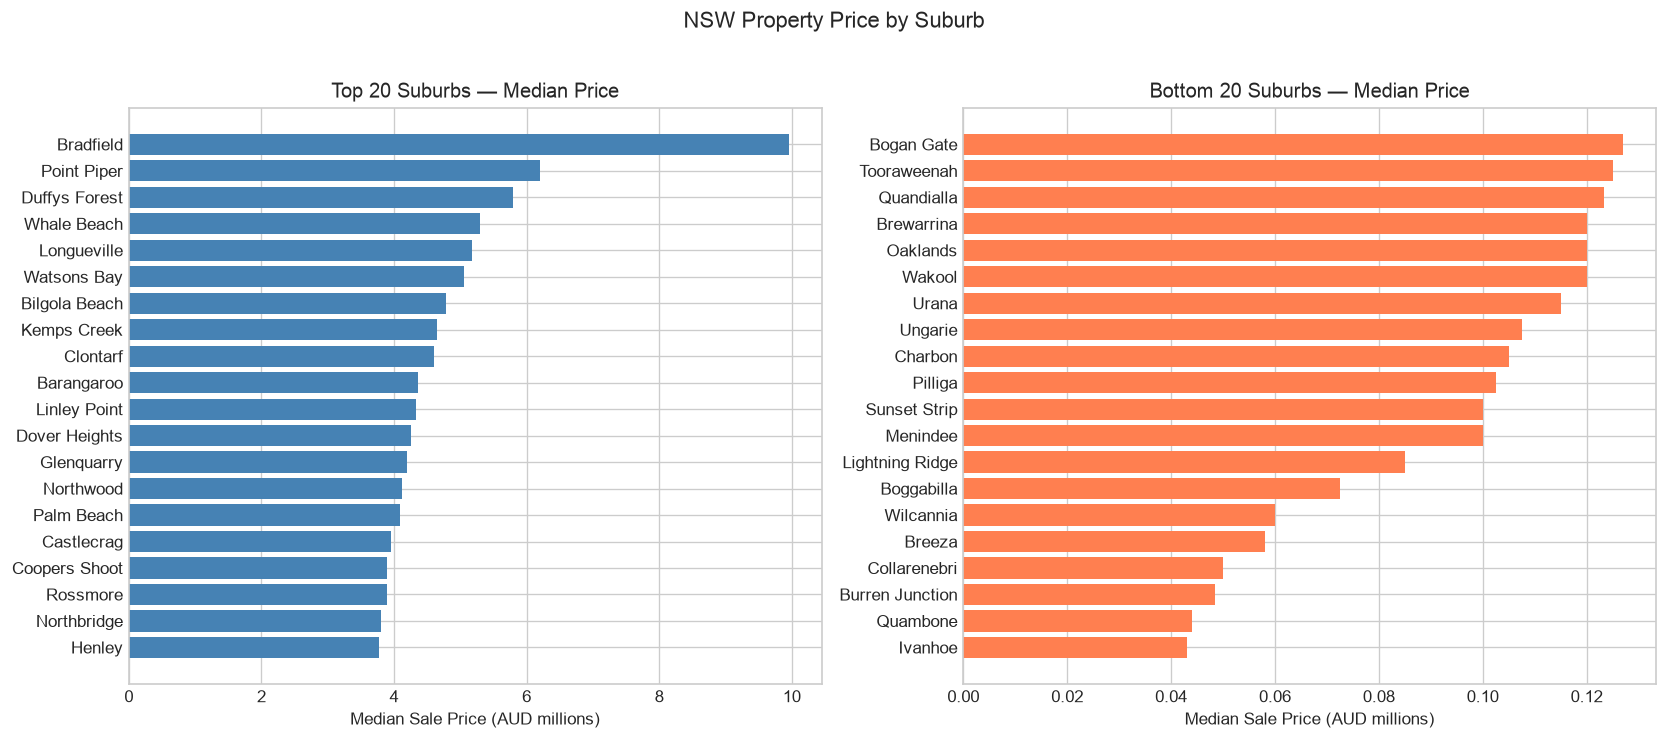

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20 most expensive suburbs
top = suburb_stats.head(20)
axes[0].barh(top.index, top["median_price"] / 1e6, color="steelblue")
axes[0].set_xlabel("Median Sale Price (AUD millions)")
axes[0].set_title("Top 20 Suburbs — Median Price")
axes[0].invert_yaxis()

# Bottom 20 (most affordable)
bot = suburb_stats.tail(20)
axes[1].barh(bot.index, bot["median_price"] / 1e6, color="coral")
axes[1].set_xlabel("Median Sale Price (AUD millions)")
axes[1].set_title("Bottom 20 Suburbs — Median Price")
axes[1].invert_yaxis()

plt.suptitle("NSW Property Price by Suburb", y=1.02, fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "suburb_prices.png", dpi=150)
plt.show()

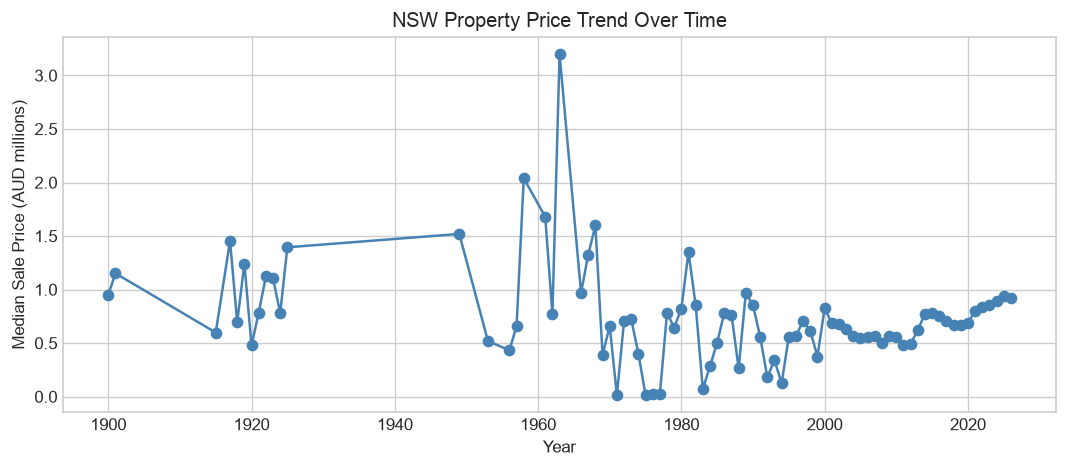

In [18]:
# Price trend over time — does the market show a clear upward trend?
yearly = (
    df.groupby("year")[PRICE_COL]
    .median()
    .reset_index()
    .rename(columns={PRICE_COL: "median_price"})
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yearly["year"], yearly["median_price"] / 1e6, marker="o", color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Median Sale Price (AUD millions)")
ax.set_title("NSW Property Price Trend Over Time")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_trend.png", dpi=150)
plt.show()

## 9. Key Takeaways

---

- **Target (price) is strongly right-skewed** (skewness = 7.32). Log-transformation reduces this to 0.29, making it suitable as a regression target. All models predict `log1p(price)`; predictions are exponentiated back to AUD for reporting.

- **Missing values:** `area` is missing in 23% of rows — imputed with suburb median, since lot sizes differ substantially between inner-city and regional areas. `suburb` and `purchase_price` are reliable (<0.1% missing).

- **Suburb is the strongest price driver** — median price ranges from under $200k (remote regional NSW) to $9.95M (Bradfield). There are 4,021 unique suburbs; one-hot encoding is infeasible. Target encoding (suburb mean log-price, computed on train set only) is the correct approach for this cardinality.

- **Land area** has a weak raw correlation with price (~0.03) due to unit inconsistencies and corrupt values in the source data. After standardisation and capping, it becomes a useful feature with a positive log-linear relationship.

- **Market trend is visible** — `year` has a moderate positive correlation (~0.17) with log-price, reflecting NSW property appreciation from 2010 to 2026. Year will be included as a feature.

- **Outliers:** 8.5% IQR price outliers. A hard filter of [$50k, $30M] removes data-quality issues while retaining all genuine transactions. Area corrupt values (up to 2.7 billion m²) will be capped at 500,000 m².